<a href="https://colab.research.google.com/github/munawirmt/prediction-models/blob/main/KNN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN ALGORITHM MODEL

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

In [ ]:
#load data
data = load_breast_cancer()
X = data.data
y = data.target
print(f"Dataset Shape: {X.shape}")
print(f"Target Classes: {data.target_names}")


Dataset Shape: (569, 30)
Target Classes: ['malignant' 'benign']


In [ ]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
#feature scaling(for knn distance calculations)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#train knn classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
#make predictions and check accuracy
y_pred = knn.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Model Accuracy: 95.61%

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



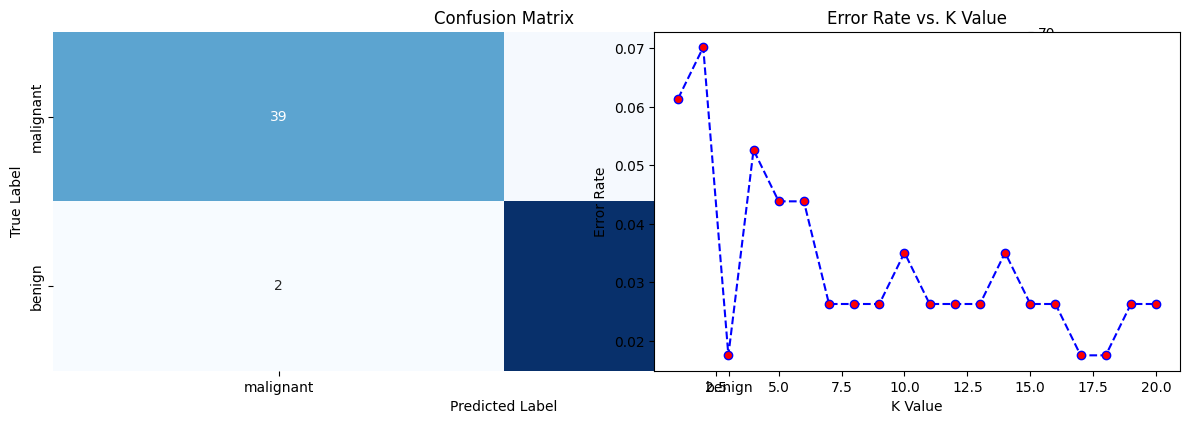

In [ ]:
#visualizations
plt.figure(figsize=(12, 5))

#confusion metrics
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

#best k value find (optimization curve)
plt.subplot(1, 2, 2)
error_rates = []
for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    error_rates.append(np.mean(preds != y_test))

plt.plot(range(1, 21), error_rates, color="blue", linestyle="--", marker="o", markerfacecolor="red")
plt.title("Error Rate vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Error Rate")

plt.tight_layout()
plt.show()

# For production purpose use following model

In [ ]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Load Data & Split
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42, stratify=data.target
)

# Build Pipeline (Prevents Data Leakage)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Define Hyperparameter Search Grid
param_grid = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

#Perform 5-Fold Cross-Validation Search
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

#Output Best Hyperparameters
best_model = grid_search.best_estimator_
print(f"Best Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_ * 100:.2f}%\n")

#Evaluate on Hold-out Test Set
y_pred = best_model.predict(X_test)
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

#Save Model Artifact for Deployment
joblib.dump(best_model, "knn_breast_cancer_pipeline.pkl")
print("\nPipeline saved successfully as 'knn_breast_cancer_pipeline.pkl'")

Best Parameters Found: {'knn__metric': 'euclidean', 'knn__n_neighbors': 8, 'knn__weights': 'distance'}
Best Cross-Validation Accuracy: 97.36%

Test Set Accuracy: 97.37%

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        42
      benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Pipeline saved successfully as 'knn_breast_cancer_pipeline.pkl'


how to use it in production with (flask api / fast api)

In [ ]:
import joblib
import numpy as np

#Load the single pipeline file (includes both scaler and trained KNN model)
model_pipeline = joblib.load("knn_breast_cancer_pipeline.pkl")

#Raw feature array from API request
new_patient_data = np.array([[17.99, 10.38, 122.8, 1001.0, 0.1184, 0.2776, 0.3001,
                              0.1471, 0.2419, 0.07871, 1.095, 0.9053, 8.589, 153.4,
                              0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
                              25.38, 17.33, 184.6, 2019.0, 0.1622, 0.6656, 0.7119,
                              0.2654, 0.4601, 0.1189]])

#Predict directly (pipeline handles scaling automatically)
prediction = model_pipeline.predict(new_patient_data)
print(f"Predicted Class: {data.target_names[prediction[0]]}")

Predicted Class: malignant
